In [1]:
from envs.fourrooms import FourRoomsExactValue
from core.config import config 
import gymnax 
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

env, env_params = gymnax.make(config["ENV_NAME"], use_visual_obs=True, goal_fixed=(11,11), pos_fixed = (3,1))
env_params = env_params.replace(
        max_steps_in_episode=config['MAX_STEPS_IN_EPISODE'], 
        fail_prob=config['FAIL_PROB']
)
evaluator = FourRoomsExactValue(start_pos = env.pos_fixed, goal_pos = env.goal_fixed, fail_prob= env_params.fail_prob) # for computing the true 

In [2]:
def random_policy(_):
    m = evaluator.num_actions
    return jnp.ones(m) / m

jax.vmap(random_policy)(evaluator.obs_stack).shape

(104, 4)

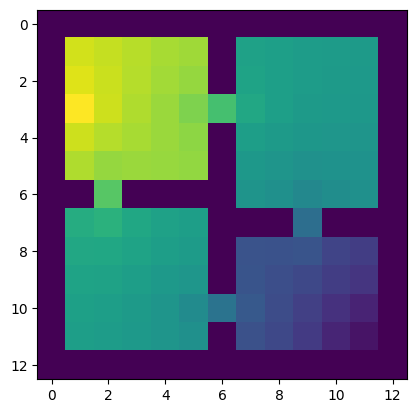

In [7]:
target_policy_probs = jax.vmap(random_policy)(evaluator.obs_stack)
pi = jnp.vstack([target_policy_probs, target_policy_probs[0]])
pi_full = pi
V_pi = evaluator.compute_true_values_raw(pi) 
mu = evaluator.compute_stationary_distribution(target_policy_probs)
plt.imshow(mu)

In [ ]:
# Solving LSTD, getting Phi:
from core.networks import *
rng = jax.random.PRNGKey(0)
network = PQN_AC(env.action_space(env_params).n, norm_type = 'layer_norm' if config["LAYER_NORM"] else "")

rng, init_rng = jax.random.split(rng)
init_x = jnp.zeros(env.observation_space(env_params).shape)
params = network.init(init_rng, init_x)


In [ ]:
# next lets solve for different value functios LTSD, BR, and VR
# step 1: get Phi (don't forget terminal state)!
pi = target_policy_probs
Φ = network.apply(params, evaluator.obs_stack, method=network.value_features)
Φ = jnp.vstack([Φ, jnp.zeros((1, Φ.shape[-1]))]) 

# Get the MDP dynamics for solving (note reward is awarded at the next state)
P = evaluator.P
P_π = jnp.einsum("sa,sam->sm", pi_full, P)
R_π_s = jnp.einsum("sa,sa->s", pi_full, evaluator.R_extrinsic)
R_π = P_π @ R_π_s

# Get the visitation array 
mu = evaluator.compute_discounted_visitation_raw(pi)
mu = jnp.append(mu, 0.0)
D = jnp.diag(mu)

γ = config['GAMMA']

# LSTD
X = D @ (Φ - γ * P_π @ Φ)
A = Φ.T @ X
b = Φ.T @ D @ R_π

eps =  1e-6 * jnp.eye(A.shape[-1])
w_lstd = jnp.linalg.solve(A + eps, b)
V_lstd = Φ @ w_lstd

# Bellman Residual Minimization
X = (Φ - γ * P_π @ Φ)
w_br = jnp.linalg.solve(X.T @ D @ X + eps, X.T @ D @ R_π)
V_br = Φ @ w_br

# Value Residual Minimization:
V_true = evaluator.compute_true_values_raw(pi)

# 2. Solve the D-weighted least squares projection
# Use the same ridge penalty for a fair comparison
w_vr = jnp.linalg.solve(Φ.T @ D @ Φ + eps, Φ.T @ D @ V_true)
V_vr = Φ @ w_vr

w_vr_unweighted = jnp.linalg.solve(Φ.T @ Φ + eps, Φ.T @ V_true)
V_vr_unweighted = Φ @ w_vr_unweighted

In [6]:
# Take a look at the MSBE and MSPBE:
def get_errors(v):
    Π_φ = Φ @ jnp.linalg.pinv(Φ.T @ D @ Φ) @ Φ.T @ D # projection matrix
    T = lambda v: R_π + γ * P_π @ v
    # errors:
    BE = T(v) - v
    PBE = Π_φ @ BE
    VE = V_pi - v
    return {'BE': BE, 'PBE': PBE, 'VE': VE}

BR_Errors = get_errors(V_br)
BR_mse = jax.tree.map(lambda x: jnp.mean((D@x)**2), BR_Errors)
LSTD_Errors = get_errors(V_lstd)
LSTD_mse = jax.tree.map(lambda x: jnp.mean(D @ x**2), LSTD_Errors)
VR_Errors = get_errors(V_vr)
VR_mse = jax.tree.map(lambda x: jnp.mean(D @ x**2), VR_Errors)

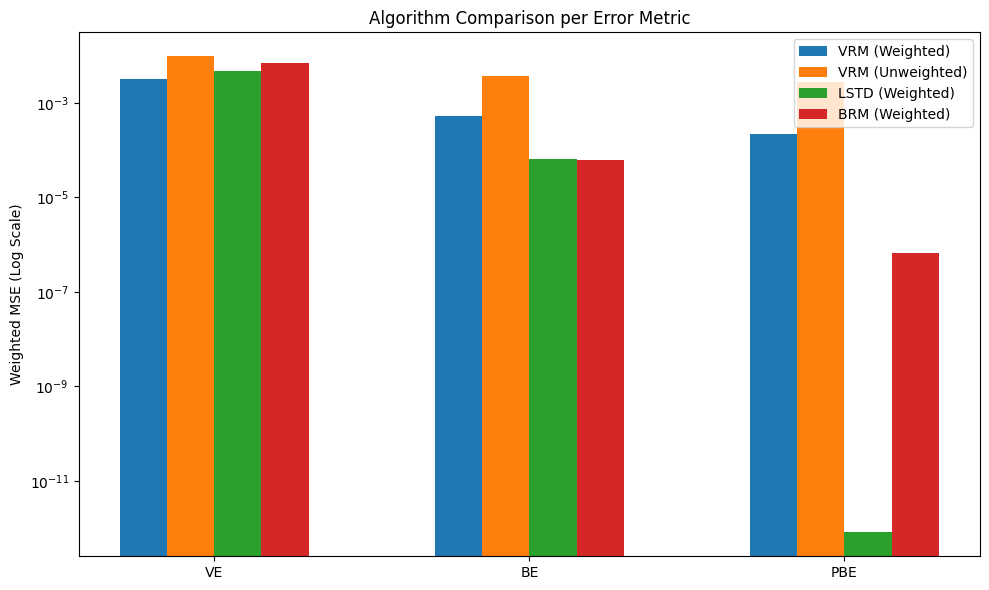

In [19]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np

def plot_error_bars_by_metric(fits_dict, get_errors_fn, mu, log_scale=True):
    fit_names = list(fits_dict.keys())
    error_keys = ['VE', 'BE', 'PBE'] 
    
    # Key the dictionary by Fit Name instead of Error Type
    wmse_data = {fit: [] for fit in fit_names}
    
    for fit_name, V_pred in fits_dict.items():
        errors = get_errors_fn(V_pred)
        for key in error_keys:
            wmse = jnp.sum(mu * (errors[key] ** 2))
            wmse_data[fit_name].append(wmse)

    # Setup the grouped bar chart dimensions for the x-axis (Error Types)
    x = np.arange(len(error_keys))
    width = 0.15  # Adjust width based on how many algorithms you have
    multiplier = 0
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot each algorithm as a separate set of bars across the error types
    for fit_name, wmse_list in wmse_data.items():
        offset = width * multiplier
        ax.bar(x + offset, wmse_list, width, label=fit_name)
        multiplier += 1

    # Formatting
    ax.set_ylabel('Weighted MSE')
    ax.set_title('Algorithm Comparison per Error Metric')
    
    # Center the x-ticks under each group of algorithms
    ax.set_xticks(x + width * (len(fit_names) - 1) / 2)
    ax.set_xticklabels(error_keys)
    ax.legend(loc='upper right')
    
    if log_scale:
        ax.set_yscale('log')
        ax.set_ylabel('Weighted MSE (Log Scale)')
        
    plt.tight_layout()
    plt.show()

plot_error_bars_by_metric(fits, get_errors, mu)

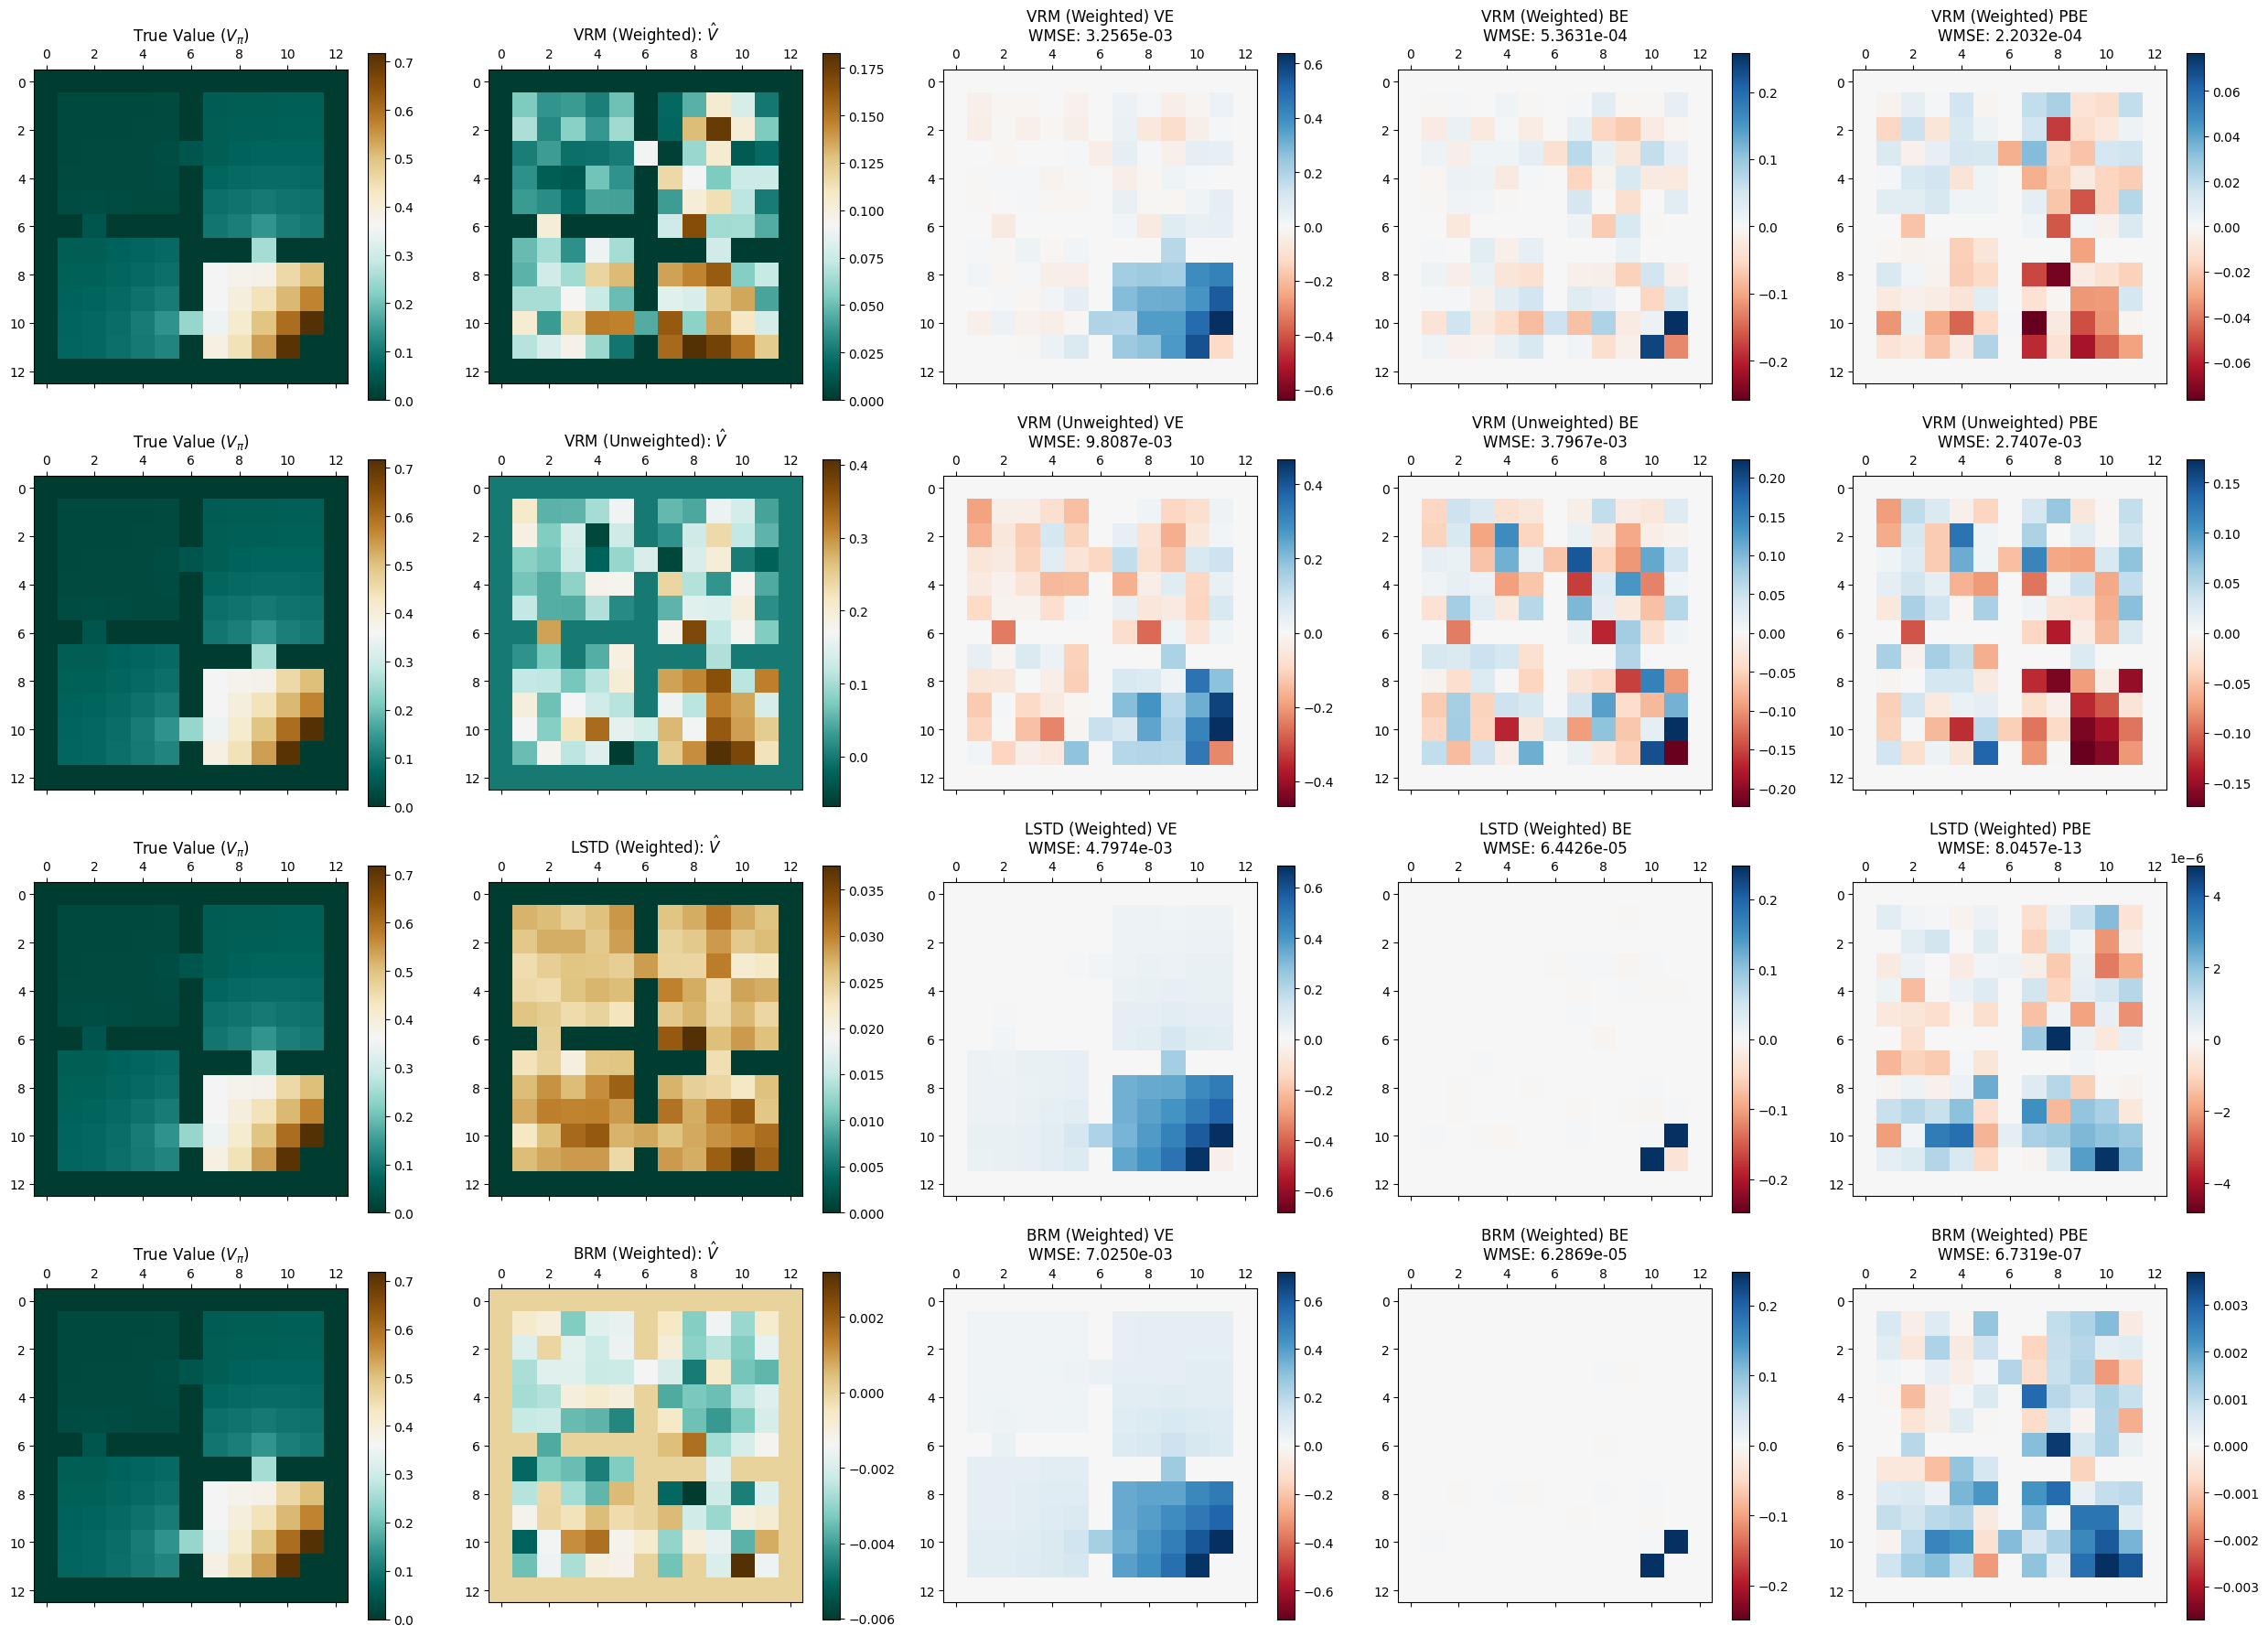

In [20]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

def plot_value_fits(fits_dict, V_pi, get_errors_fn, evaluator, mu):
    """
    Plots a grid of value function fits and their corresponding errors.
    
    Args:
        fits_dict (dict): Dictionary mapping fit names to their predicted value arrays (e.g., {'LSTD': V_lstd}).
        V_pi (array): The true value function array.
        get_errors_fn (callable): Function that takes V_pred and returns a dict of errors.
        evaluator (object): Evaluator object with a `get_value_grid` method.
        mu (array): State visitation distribution for weighted MSE.
    """
    num_fits = len(fits_dict)
    # Create a grid: rows = number of fits, cols = 5 (True V, Pred V, VE, BE, PBE)
    fig, axes = plt.subplots(num_fits, 5, figsize=(25, 4.5 * num_fits))
    
    # Ensure axes is 2D even if you pass a single fit
    if num_fits == 1:
        axes = axes[jnp.newaxis, :]

    for row_idx, (fit_name, V_pred) in enumerate(fits_dict.items()):
        # Calculate errors dynamically using your function
        errors = get_errors_fn(V_pred)
        
        # --- (a) True Value ---
        ax_true = axes[row_idx, 0]
        im_true = ax_true.matshow(evaluator.get_value_grid(V_pi), cmap='BrBG_r')
        ax_true.set_title("True Value ($V_{\pi}$)")
        fig.colorbar(im_true, ax=ax_true)
        
        # --- (b) Predicted Value ---
        ax_pred = axes[row_idx, 1]
        im_pred = ax_pred.matshow(evaluator.get_value_grid(V_pred), cmap='BrBG_r')
        ax_pred.set_title(f"{fit_name}: $\hat{{V}}$")
        fig.colorbar(im_pred, ax=ax_pred)
        
        # --- (c, d, e) Errors ---
        error_keys = ['VE', 'BE', 'PBE']
        for col_idx, err_name in enumerate(error_keys, start=2):
            ax_err = axes[row_idx, col_idx]
            err_vec = errors[err_name]
            
            # State-weighted MSE for the title
            wmse = jnp.sum(mu * (err_vec ** 2))
            
            # Extract absolute max to perfectly center the RdBu colormap at 0
            max_abs = jnp.max(jnp.abs(err_vec))
            max_abs = max_abs if max_abs > 0 else 1e-6 
            
            im_err = ax_err.matshow(evaluator.get_value_grid(err_vec), 
                                    cmap='RdBu', vmin=-max_abs, vmax=max_abs)
            ax_err.set_title(f"{fit_name} {err_name}\nWMSE: {wmse:.4e}")
            fig.colorbar(im_err, ax=ax_err)
            
    plt.tight_layout()
    plt.show()

# Assuming V_vr_w, V_vr_u, V_lstd, V_br are your calculated vectors
fits = {
    'VRM (Weighted)': V_vr,
    'VRM (Unweighted)': V_vr_unweighted,
    'LSTD (Weighted)': V_lstd,
    'BRM (Weighted)': V_br
}

plot_value_fits(fits, V_pi, get_errors, evaluator, mu)

In [21]:
def compute_greedy_policy(v):
    P = evaluator.P
    R = evaluator.R_extrinsic
    γ = config['GAMMA']
    
    # 1. Get the pure state-reward (Reward is 1.0 across all actions at the goal)
    R_state = jnp.mean(R, axis=-1)
    
    # 2. Shift the reward backward to the transition
    # P is (S, A, S), R_state is (S,) -> outputs (S, A)
    R_shifted = jnp.einsum("sam,m->sa", P, R_state)
    
    # 3. Expected next state value
    expected_v = jnp.einsum("sam,m->sa", P, v)
    
    # 4. Assemble Q and argmax
    Qs = R_shifted + γ * expected_v
    return jnp.argmax(Qs, axis=-1)

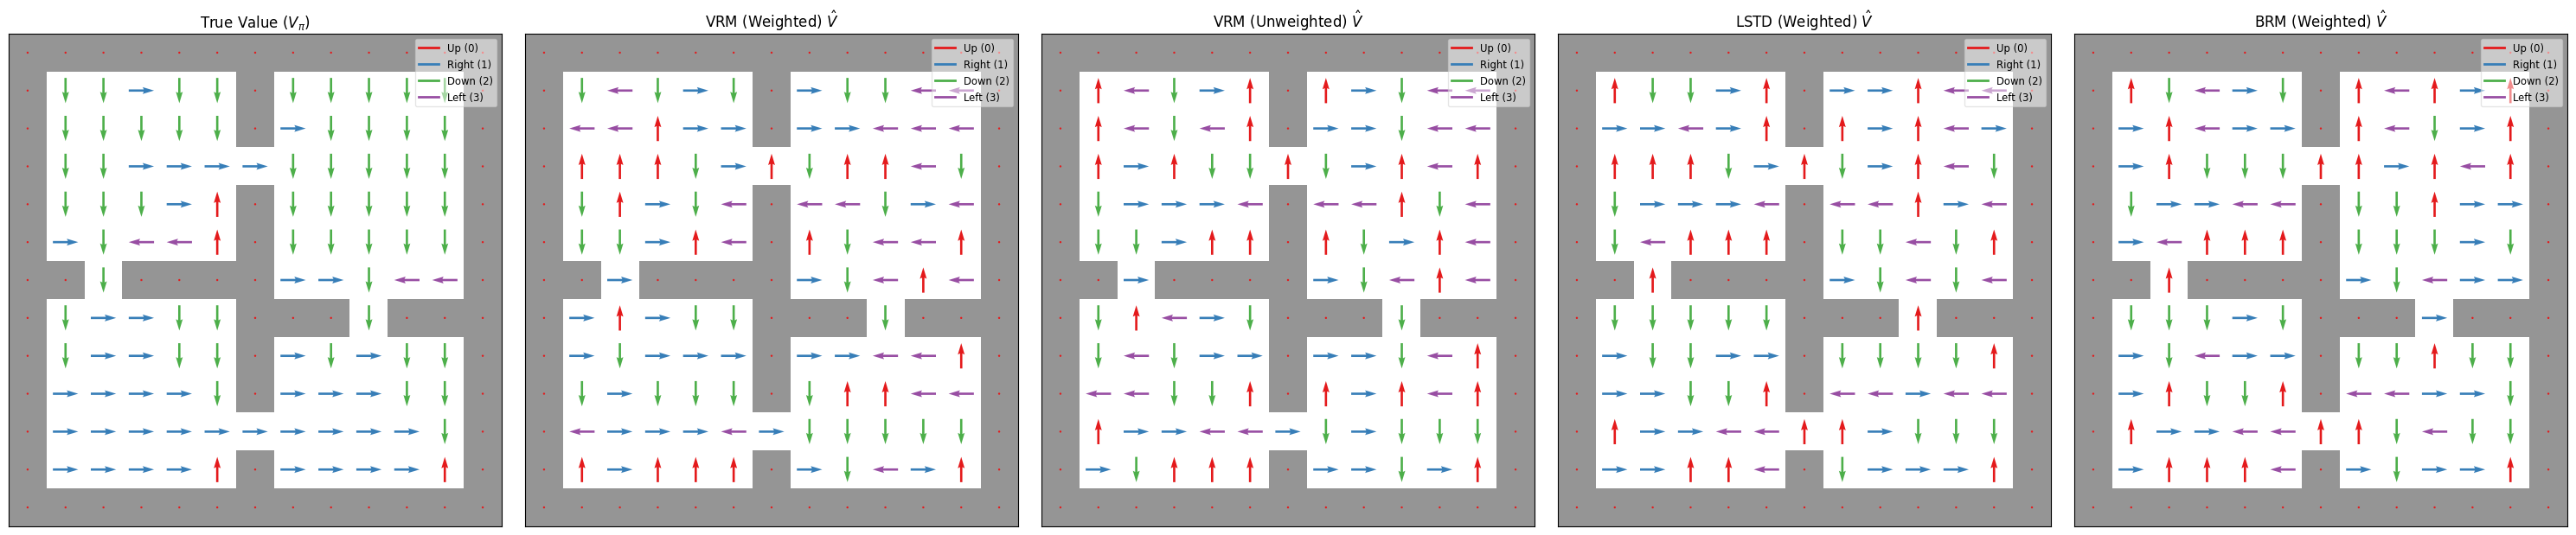

In [22]:
import matplotlib.colors as colors # Add this at the top of your file if not there

def plot_policy_flow_q(fits_dict, V_pi, evaluator, target_policy_probs, config):
    """
    Plots uniform-length arrows showing the implied greedy policy, 
    colored categorically by the chosen action.
    """
    num_plots = 1 + len(fits_dict)
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6))
    
    if num_plots == 1: 
        axes = [axes]
        
    env_map = np.array(evaluator.env_map)
    H, W = env_map.shape
    X, Y = np.meshgrid(np.arange(W), np.arange(H))
    

    def overlay_greedy_policy(ax, greedy_pi_flat, title):
        # 1. Background and Title
        ax.imshow(~env_map, cmap='Greys', vmin=0, vmax=2)
        ax.set_title(title)
        ax.set_xticks([]); ax.set_yticks([])

        # 2. Reshape to grid
        greedy_pi_grid = np.array(evaluator.get_value_grid(greedy_pi_flat))
        
        # 3. Action Vector Mapping (Gymnax)
        action_dy = np.array([-1, 0, 1, 0]) 
        action_dx = np.array([0, 1, 0, -1])
        dx = action_dx[greedy_pi_grid]
        dy = action_dy[greedy_pi_grid]
        
        # 4. Masking
        dx[~env_map] = 0
        dy[~env_map] = 0
        
        # 5. Define 4 High-Contrast Colors
        # 0: Up, 1: Right, 2: Down, 3: Left
        action_colors = np.array(['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']) 
        color_grid = action_colors[greedy_pi_grid]
        
        # 6. Plotting
        # We pass the flat color array directly to the 'color' argument 
        # rather than using 'C' and 'cmap' to avoid normalization issues.
        H, W = env_map.shape
        X, Y = np.meshgrid(np.arange(W), np.arange(H))
        
        ax.quiver(X, Y, dx, dy, color=color_grid.flatten(), pivot='mid', 
                scale=1.5, scale_units='xy', angles='xy')

        # 7. Add a manual legend instead of a messy colorbar
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='#e41a1c', lw=2, label='Up (0)'),
            Line2D([0], [0], color='#377eb8', lw=2, label='Right (1)'),
            Line2D([0], [0], color='#4daf4a', lw=2, label='Down (2)'),
            Line2D([0], [0], color='#984ea3', lw=2, label='Left (3)')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize='small', framealpha=0.5)   
        

    # Draw True Value first (assuming compute_greedy_policy is defined elsewhere)
    greedy_pi_flat_true = compute_greedy_policy(V_pi)
    overlay_greedy_policy(axes[0], greedy_pi_flat_true, "True Value ($V_{\pi}$)")
    
    # Draw approximations
    for i, (fit_name, V_pred) in enumerate(fits_dict.items(), start=1):
        greedy_pi_flat = compute_greedy_policy(V_pred)
        overlay_greedy_policy(axes[i], greedy_pi_flat, f"{fit_name} $\hat{{V}}$")
        
    plt.tight_layout()
    plt.show()


plot_policy_flow_q(fits, V_pi, evaluator, target_policy_probs, config)

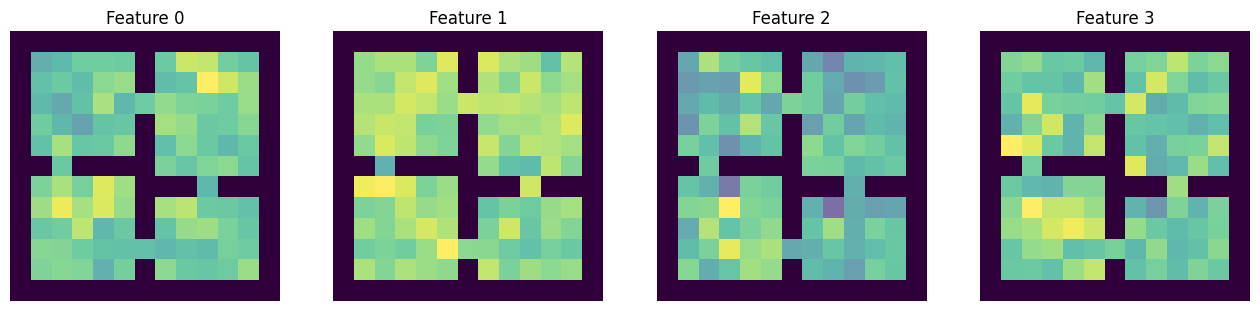

In [28]:
import matplotlib.pyplot as plt

# Φ is shape (105, k). Let's plot the first 4 features.
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    # Extract the i-th feature column
    feature_vector = Φ[:, i] 
    
    # Map it back to the grid using your exact method
    feature_grid = evaluator.get_value_grid(feature_vector)
    
    ax = axes[i]
    im = ax.imshow(feature_grid, cmap='viridis')
    ax.imshow(~np.array(evaluator.env_map), cmap='Greys', alpha=0.3) # Overlay walls
    ax.set_title(f"Feature {i}")
    ax.axis('off')
plt.show()

Text(0.5, 1.0, 'PCA of Feature Space colored by True Value')

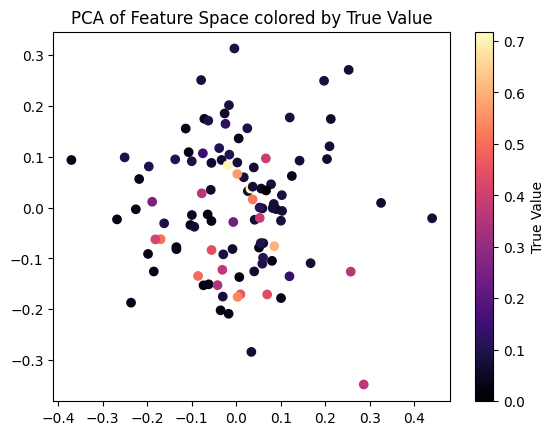

In [ ]:
from sklearn.decomposition import PCA

# Reduce the 104 standard states (exclude terminal) from k dims to 2 dims
pca = PCA(n_components=2)
phi_2d = pca.fit_transform(Φ[:-1, :]) 

plt.scatter(phi_2d[:, 0], phi_2d[:, 1], c=V_true[:-1], cmap='magma')
plt.colorbar(label="True Value")
plt.title("PCA of Feature Space colored by True Value")

# Compute singular values of the feature matrix
_, S, _ = jnp.linalg.svd(Φ, full_matrices=False)

# Track the effective rank (e.g., how many singular values are > 0.01)
effective_rank = jnp.sum(S > 0.01)
effective_rank

def get_projection_angle(v):
    "Measure of how good the features are at measuring the value. Cosine of the angle."
    Π_φ = Φ @ jnp.linalg.pinv(Φ.T @ D @ Φ) @ Φ.T @ D # projection matrix
    d_weights = jnp.diag(D)
    alignment = jnp.sqrt(jnp.sum(d_weights * (Π_φ @ V_pi)**2)) / jnp.sqrt(jnp.sum(d_weights * (V_pi)**2))
    return alignment

get_projection_angle(V_pi)

def get_prediction_alignment(v_pred, V_pi, D):
    "Cosine Similarity: higher is better"
    d_weights = jnp.diag(D)
    
    # D-weighted inner product: <v_pred, V_pi>_D = sum( d * v_pred * V_pi )
    inner_product = jnp.sum(d_weights * v_pred * V_pi)
    
    # D-norms
    norm_pred = jnp.sqrt(jnp.sum(d_weights * (v_pred ** 2)))
    norm_true = jnp.sqrt(jnp.sum(d_weights * (V_pi ** 2)))
    
    return inner_product / (norm_pred * norm_true)


get_prediction_alignment(V_br, V_pi, D)


In [ ]:
# Compute singular values of the feature matrix
_, S, _ = jnp.linalg.svd(Φ, full_matrices=False)

# Track the effective rank (e.g., how many singular values are > 0.01)
effective_rank = jnp.sum(S > 0.01)
effective_rank

def get_projection_angle(v):
    "Measure of how good the features are at measuring the value. Cosine of the angle."
    Π_φ = Φ @ jnp.linalg.pinv(Φ.T @ D @ Φ) @ Φ.T @ D # projection matrix
    d_weights = jnp.diag(D)
    alignment = jnp.sqrt(jnp.sum(d_weights * (Π_φ @ V_pi)**2)) / jnp.sqrt(jnp.sum(d_weights * (V_pi)**2))
    return alignment

get_projection_angle(V_pi)

def get_prediction_alignment(v_pred, V_pi, D):
    "Cosine Similarity: higher is better"
    d_weights = jnp.diag(D)
    
    # D-weighted inner product: <v_pred, V_pi>_D = sum( d * v_pred * V_pi )
    inner_product = jnp.sum(d_weights * v_pred * V_pi)
    
    # D-norms
    norm_pred = jnp.sqrt(jnp.sum(d_weights * (v_pred ** 2)))
    norm_true = jnp.sqrt(jnp.sum(d_weights * (V_pi ** 2)))
    
    return inner_product / (norm_pred * norm_true)


get_prediction_alignment(V_br, V_pi, D)


Array(23, dtype=int32)

Array(0.7085968, dtype=float32)

Array(-0.51026237, dtype=float32)